# Predicting Base Salary in STEM: An Explainable Machine Learning Study

## Project Overview

This project applies an end-to-end supervised machine learning workflow to a real-world STEM salary dataset. The objective is to build, compare, validate, and evaluate regression models for predicting an employee's base salary using professional, educational, demographic, and workplace-related characteristics.is

The analysis will focus on:

- Understanding and preprocessing the dataset
- Establishing a baseline regression model
- Performing feature engineering where appropriate
- Comparing multiple regression algorithms
- Tuning model hyperparameters using cross-validation
- Evaluating models using appropriate regression metrics
- Analyzing prediction errors and residuals
- Interpreting important features and model coefficients
- Testing model robustness across different random seeds
- Selecting and saving the final model

The project will also examine whether model performance and salary-related patterns differ across demographic groups, particularly gender, while avoiding causal claims that cannot be established from observational survey data.

## 1. Dataset Selection

### Dataset: Data Science and STEM Salaries

The dataset contains salary records collected through an online survey of workers in STEM fields from around the world. The data covers the period from June 2017 to August 2021 and includes information about compensation, professional experience, company, job title, location, education, gender, and race.

The dataset was selected because it contains a large number of observations and a mixture of numerical, categorical, binary, date/time, and free-response variables. These characteristics make it suitable for demonstrating the complete supervised machine learning workflow required for this project.

### Primary Prediction Task

The primary task will be **regression**, with `basesalary` considered as the target variable.

The goal is to investigate whether an employee's professional and other observable characteristics can be used to predict their base salary.

The dataset will be inspected carefully before finalizing the feature set so that variables that directly contain or reveal the target are not used as predictors.

### Dataset Source

The original dataset is titled **"Data Science and STEM Salaries"** and was collected from an online salary survey.

Source: Kaggle — Data Science and STEM Salaries

The accompanying codebook is used to understand the meaning, type, and intended interpretation of the variables before preprocessing.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

## 2. Data Loading

The dataset was provided as an Excel file. It will be loaded into a Pandas DataFrame so that its structure, data types, missing values, and distributions can be examined before any preprocessing decisions are made.

In [3]:
file_path = "stem-4_25-update-1.xlsx"
df = pd.read_excel(file_path)
df.head()

,row_number,order_received,timestamp,company,level,title,totalyearlycompensation,location,city,nation,yearsofexperience,yearsatcompany,tag,basesalary,stockgrantvalue,bonus,gender,otherdetails,cityid,dmaid,masters_01,bachelors_01,phd_01,highschool_01,somecol_01,asian_01,white_01,multirace_01,black_01,hispanic_01,race,education
0,70138,52474,2021-05-17 09:12:00,Amazon,L4,Software Engineer,114000,"Aachen, NW, Germany",Aachen,Germany,4.0,0.0,ML / AI,97000,12000.0,4000.0,Male,"Title: Applied Scientist, Race: Asian, Academi...",3645,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,Asian,Master's Degree
1,22027,17072,2020-02-08 08:44:00,Amazon,SDE II,Software Engineer,109000,"Aachen, NW, Germany",Aachen,Germany,3.0,1.0,ML / AI,85000,10000.0,10000.0,Male,NaN,3645,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,13236,10495,2019-08-16 08:42:00,Amazon,L5,Software Engineer,112000,"Aachen, NW, Germany",Aachen,Germany,5.0,0.0,API Development (Back-End),87000,2000.0,23000.0,Male,NaN,3645,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,80850,60517,2021-08-01 04:57:00,Uber,L6,Software Engineer,418000,"Aarhus, AR, Denmark",Aarhus,Denmark,10.0,0.0,Distributed Systems (Back-End),240000,130000.0,48000.0,Male,"Title: Staff Swe, Race: White, Academic Level:...",12962,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,White,Bachelor's Degree
4,50307,37373,2020-12-04 09:06:00,Uber,L5a,Software Engineer,376000,"Aarhus, AR, Denmark",Aarhus,Denmark,4.0,4.0,Distributed Systems (Back-End),160000,165000.0,50000.0,Male,"Title: Senior Software Engineer, Race: White, ...",12962,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,White,PhD


## 3. Initial Dataset Inspection

The first inspection will establish the dimensions of the dataset and provide an initial view of the observations. No rows or columns will be removed at this stage.

In [5]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 62642
Number of columns: 32


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62642 entries, 0 to 62641
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   row_number               62642 non-null  int64         
 1   order_received           62642 non-null  int64         
 2   timestamp                62642 non-null  datetime64[ns]
 3   company                  62630 non-null  object        
 4   level                    62519 non-null  object        
 5   title                    62642 non-null  object        
 6   totalyearlycompensation  62642 non-null  int64         
 7   location                 62642 non-null  object        
 8   city                     62642 non-null  object        
 9   nation                   62642 non-null  object        
 10  yearsofexperience        62642 non-null  float64       
 11  yearsatcompany           62642 non-null  float64       
 12  tag                      61669 n

In [7]:
df.describe()

,row_number,order_received,timestamp,totalyearlycompensation,yearsofexperience,yearsatcompany,basesalary,stockgrantvalue,bonus,cityid,dmaid,masters_01,bachelors_01,phd_01,highschool_01,somecol_01,asian_01,white_01,multirace_01,black_01,hispanic_01
count,62642.000000,62642.000000,62642,6.264200e+04,62642.000000,62642.000000,6.264200e+04,6.264200e+04,62642.000000,62642.000000,62640.000000,30370.000000,30370.000000,30370.000000,30370.000000,30370.000000,22427.000000,22427.000000,22427.000000,22427.000000,22427.000000
mean,41694.723732,31321.500000,2020-07-17 03:29:38.906803712,2.163004e+05,7.204135,2.702093,1.366873e+05,5.148608e+04,19334.746588,9856.201989,616.097222,0.506783,0.415048,0.059368,0.010537,0.011689,0.524903,0.358140,0.035850,0.030766,0.050386
min,1.000000,1.000000,2017-06-07 11:33:00,1.000000e+04,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,20069.250000,15661.250000,2020-01-11 23:12:45,1.350000e+05,3.000000,0.000000,1.080000e+05,0.000000e+00,1000.000000,7369.000000,506.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,42019.000000,31321.500000,2020-09-21 16:31:00,1.880000e+05,6.000000,2.000000,1.400000e+05,2.500000e+04,14000.000000,7839.000000,807.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
75%,63021.750000,46981.750000,2021-03-26 15:18:30,2.640000e+05,10.000000,4.000000,1.700000e+05,6.500000e+04,26000.000000,11521.000000,807.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000
max,83875.000000,62642.000000,2021-08-17 08:28:00,4.980000e+06,69.000000,69.000000,1.659870e+06,2.800000e+06,1000000.000000,47926.000000,881.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
std,24488.865879,18083.332118,NaN,1.380337e+05,5.840375,3.263656,6.136928e+04,8.187457e+04,26781.292040,6679.104563,289.843390,0.499962,0.492738,0.236316,0.102108,0.107484,0.499391,0.479464,0.185919,0.172688,0.218744


### Initial Observations

The dataset contains 62,642 observations and 32 variables in the provided Excel file. The variables include numerical measures such as years of experience and salary, categorical variables such as gender, race, education, company, and job title, as well as date/time and free-response fields.

The data types and missing-value patterns will be examined further before deciding which variables require cleaning, transformation, encoding, or removal.

In [7]:
df.columns

Index(['row_number', 'order_received', 'timestamp', 'company', 'level',
       'title', 'totalyearlycompensation', 'location', 'city', 'nation',
       'yearsofexperience', 'yearsatcompany', 'tag', 'basesalary',
       'stockgrantvalue', 'bonus', 'gender', 'otherdetails', 'cityid', 'dmaid',
       'masters_01', 'bachelors_01', 'phd_01', 'highschool_01', 'somecol_01',
       'asian_01', 'white_01', 'multirace_01', 'black_01', 'hispanic_01',
       'race', 'education'],
      dtype='object')

## 4. Variable Overview

The dataset contains several different types of variables.

### Target candidate
- `basesalary` — employee's base salary

### Professional and workplace variables
- `company`
- `level`
- `title`
- `yearsofexperience`
- `yearsatcompany`
- `location`
- `city`
- `nation`

### Compensation variables
- `basesalary`
- `totalyearlycompensation`
- `stockgrantvalue`
- `bonus`

### Demographic variables
- `gender`
- `race`

### Education variables
- `education`
- `masters_01`
- `bachelors_01`
- `phd_01`
- `highschool_01`
- `somecol_01`

### Other variables
- `timestamp`
- `row_number`
- `order_received`
- `cityid`
- `dmaid`
- `tag`
- `otherdetails`

The codebook identifies `basesalary`, `totalyearlycompensation`, `yearsofexperience`, `yearsatcompany`, `stockgrantvalue`, and `bonus` as interval variables, while gender, race, education, company, title, and other fields are categorical or free-response variables. 

## 5. Initial Data Quality Check

Before preprocessing, the dataset will be evaluated for:

- Missing values
- Duplicate observations
- Incorrect or unexpected data types
- Unusual categorical values
- Potential outliers
- Variables that may cause data leakage

No observations will be removed solely because they appear unusual. Each preprocessing decision will be based on the structure and meaning of the variables and will be documented.

In [58]:
missing_values = pd.DataFrame({"Missing Count": df.isnull().sum(),"Missing Percentage": (df.isnull().mean() * 100).round(2)})
missing_values = missing_values.sort_values(by="Missing Percentage",ascending=False)
missing_values

,Missing Count,Missing Percentage
race,40215,64.20
hispanic_01,40215,64.20
asian_01,40215,64.20
white_01,40215,64.20
multirace_01,40215,64.20
black_01,40215,64.20
phd_01,32272,51.52
highschool_01,32272,51.52
education,32272,51.52
somecol_01,32272,51.52


In [59]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


## 6. Missing Value Analysis

As we see, missing values are present in several variables. Before deciding how to handle them, their frequency and distribution will be examined.

This is particularly important for demographic and education variables, where missingness may represent non-response or differences in how the survey information was collected.

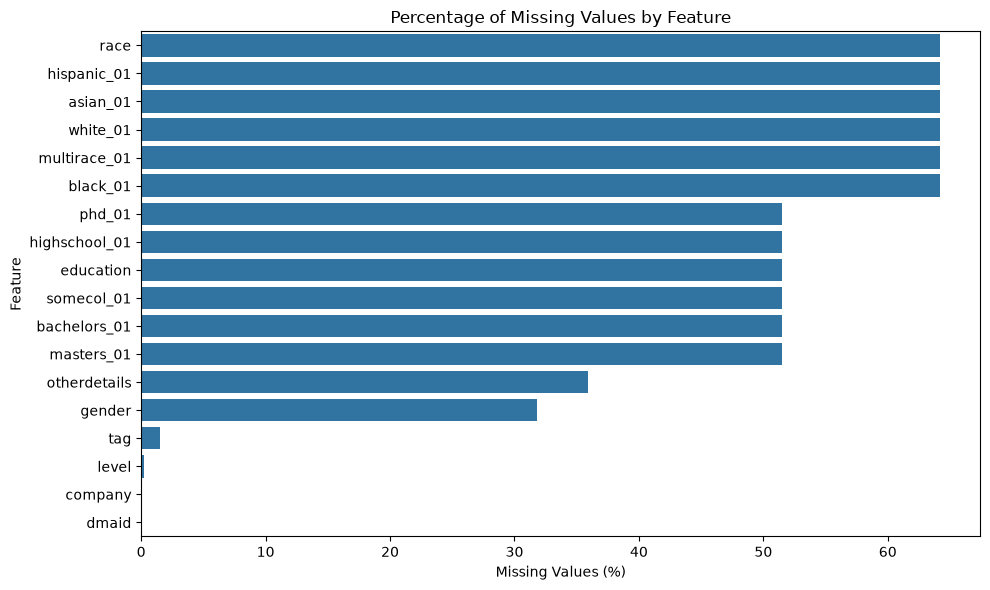

In [60]:
missing_plot = missing_values[missing_values["Missing Count"] > 0].copy()
plt.figure(figsize=(10, 6))
sns.barplot(x=missing_plot["Missing Percentage"],y=missing_plot.index)
plt.xlabel("Missing Values (%)")
plt.ylabel("Feature")
plt.title("Percentage of Missing Values by Feature")
plt.tight_layout()

### Observation

The missing-value analysis shows that missingness is concentrated in a subset of demographic and education-related variables, while most core salary and experience variables are complete.

The pattern will be considered before preprocessing rather than treating all missing values in the same way. Variables with very high missingness will be evaluated for their usefulness and suitability for modeling.

## 7. Categorical Variable Analysis

Categorical variables will be examined to understand their number of unique categories and their frequency distributions.

This is important before encoding because one-hot encoding a variable with thousands of unique values can substantially increase dimensionality and may not be appropriate without further consideration.

In [62]:
categorical_columns = df.select_dtypes(include="object").columns
categorical_summary = pd.DataFrame({"Unique Values": df[categorical_columns].nunique(),
    "Missing Values": df[categorical_columns].isnull().sum(),
    "Missing Percentage": (df[categorical_columns].isnull().mean() * 100).round(2)})

categorical_summary.sort_values("Unique Values", ascending=False)

C:\Users\MOUTAMA\AppData\Local\Temp\ipykernel_17180\4134837177.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(include="object").columns


,Unique Values,Missing Values,Missing Percentage
otherdetails,12831,22510,35.93
tag,3047,973,1.55
level,2887,123,0.20
company,1067,12,0.02
location,1042,0,0.00
city,950,0,0.00
nation,80,0,0.00
title,15,0,0.00
race,5,40215,64.20
education,5,32272,51.52


In [63]:
categorical_to_inspect = ["gender","race","education","nation","company","title","level"]

for column in categorical_to_inspect:
    print(f"\n{'=' * 60}")
    print(f"{column.upper()}")
    print(f"{'=' * 60}")
    print(df[column].value_counts(dropna=False).head(15))


GENDER
gender
Male      35702
NaN       19941
Female     6999
Name: count, dtype: int64

RACE
race
NaN            40215
Asian          11772
White           8032
Hispanic        1129
Two Or More      804
Black            690
Name: count, dtype: int64

EDUCATION
education
NaN                  32272
Master's Degree      15391
Bachelor's Degree    12601
PhD                   1703
Some College           355
Highschool             320
Name: count, dtype: int64

NATION
nation
United States     52848
India              2826
Canada             1796
United Kingdom     1195
Germany             575
Singapore           372
Ireland             323
Taiwan              312
Israel              295
Australia           263
Netherlands         256
Russia              249
Switzerland         188
Spain               100
China               100
Name: count, dtype: int64

COMPANY
company
Amazon         8204
Microsoft      5252
Google         4368
Facebook       3004
Apple          2057
Oracle         1143
S

### Observations from Categorical Variables

The categorical variables have substantially different levels of cardinality.

Variables such as gender, race, and education contain relatively few categories, whereas company, title, and particularly level contain many distinct values.

Therefore, the encoding strategy will not necessarily be identical for every categorical variable. High-cardinality variables will be examined further before deciding whether to retain, transform, group, or exclude them.

## 8. Target Variable Analysis

The primary target variable for the regression task is `basesalary`, which represents an employee's base salary.

Before training any model, the target distribution will be examined for:

- Central tendency
- Spread
- Skewness
- Zero values
- Extreme observations
- Potential outliers

This analysis will help determine whether transformations or additional preprocessing are appropriate.

In [64]:
df["basesalary"].describe(percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99])

count    6.264200e+04
mean     1.366873e+05
std      6.136928e+04
min      0.000000e+00
1%       0.000000e+00
5%       2.300000e+04
25%      1.080000e+05
50%      1.400000e+05
75%      1.700000e+05
95%      2.229500e+05
99%      2.800000e+05
max      1.659870e+06
Name: basesalary, dtype: float64

In [65]:
zero_salary_count = (df["basesalary"] == 0).sum()
zero_salary_percentage = (df["basesalary"] == 0).mean() * 100
print("Zero base salary records:", zero_salary_count)
print(f"Percentage of zero base salary records: {zero_salary_percentage:.2f}%")

Zero base salary records: 2304
Percentage of zero base salary records: 3.68%


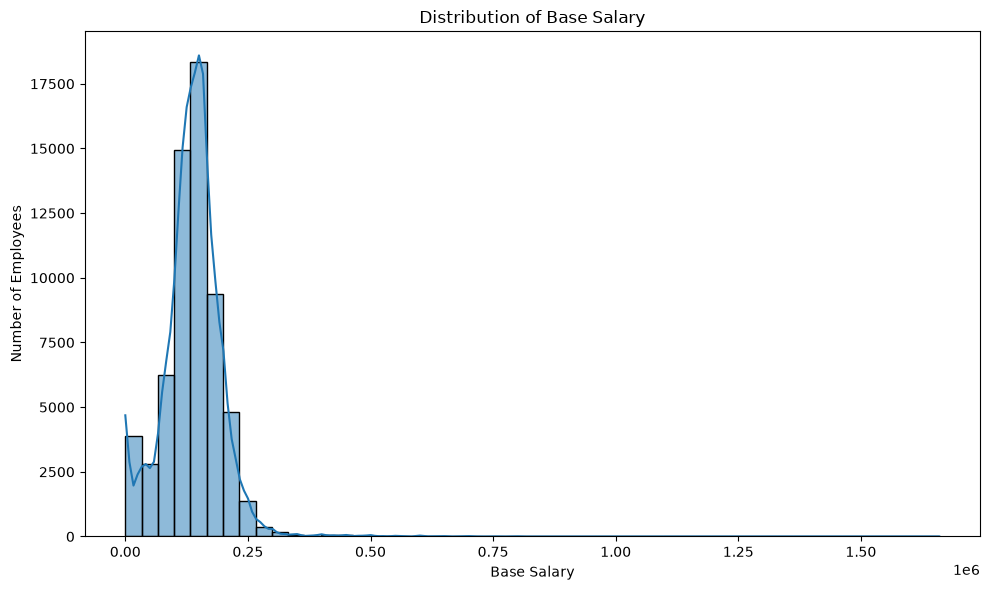

In [66]:
plt.figure(figsize=(10, 6))
sns.histplot(df["basesalary"],bins=50,kde=True)
plt.xlabel("Base Salary")
plt.ylabel("Number of Employees")
plt.title("Distribution of Base Salary")
plt.tight_layout()

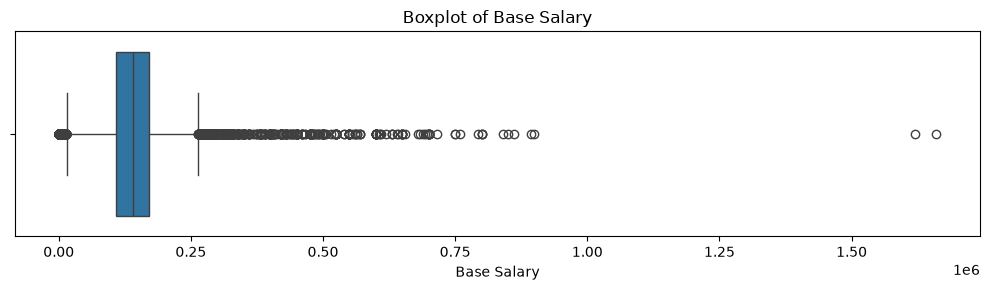

In [67]:
plt.figure(figsize=(10, 3))
sns.boxplot(x=df["basesalary"])
plt.xlabel("Base Salary")
plt.title("Boxplot of Base Salary")
plt.tight_layout()

### Target Distribution

The base salary distribution is expected to be right-skewed, with a concentration of observations at lower salary levels and a smaller number of substantially higher salaries.

The boxplot will also be used to identify potential extreme observations. However, observations identified by the IQR rule will not automatically be removed because unusually high salaries may represent genuine employees rather than data-entry errors.

The decision to retain, transform, or remove extreme observations will be made after further investigation.

## 9. Investigation of Extreme Values

Potential outliers in the target variable will be examined using percentile-based thresholds and direct inspection of the corresponding records.

The purpose of this step is to distinguish potentially valid extreme salaries from observations that may represent data-quality issues.

In [68]:
df[["basesalary","totalyearlycompensation","company","level","title","yearsofexperience","yearsatcompany","location","gender"]].sort_values("basesalary",ascending=False).head(20)

,basesalary,totalyearlycompensation,company,level,title,yearsofexperience,yearsatcompany,location,gender
34672,1659870,250000,Microsoft,64,Product Manager,13.0,13.0,"Redmond, WA",NaN
28251,1620000,162000,SquareSpace,Senior I,Software Engineer,7.0,7.0,"New York, NY",Male
31890,900000,900000,PwC,Partner / Principal,Management Consultant,22.0,4.0,"Raleigh, NC",Male
18085,893000,893000,Netflix,Senior Software Engineer,Software Engineer,19.0,8.0,"Los Gatos, CA",Male
18078,861000,861000,Netflix,Senior Software Engineer,Software Engineer,15.0,7.0,"Los Gatos, CA",Male
33950,850000,4950000,Microsoft,80,Software Engineering Manager,24.0,8.0,"Redmond, WA",Male
18084,840000,840000,Netflix,Senior Software Engineer,Software Engineer,20.0,6.0,"Los Gatos, CA",NaN
18140,800000,840000,Netflix,Senior Software Engineer,Software Engineer,8.0,5.0,"Los Gatos, CA",Male
18133,800000,800000,Netflix,Manager,Software Engineering Manager,8.0,3.0,"Los Gatos, CA",Male
17349,800000,840000,Netflix,Director,Product Manager,20.0,2.0,"Los Altos, CA",NaN


In [22]:
df[["basesalary","totalyearlycompensation","company","level","title","yearsofexperience","yearsatcompany","location","gender"]][df["basesalary"] == 0].head(20)


,basesalary,totalyearlycompensation,company,level,title,yearsofexperience,yearsatcompany,location,gender
281,0,75000,Facebook,L4 Product Manager,Product Manager,4.0,1.0,"Amsterdam, NH, Netherlands",Male
284,0,137000,Booking.com,Core,Product Designer,8.0,4.0,"Amsterdam, NH, Netherlands",NaN
286,0,120000,Booking.com,Core,Software Engineer,4.0,1.0,"Amsterdam, NH, Netherlands",Male
294,0,92000,Booking.com,F,Software Engineer,3.0,3.0,"Amsterdam, NH, Netherlands",NaN
299,0,120000,Booking.com,Senior Product Manager,Product Manager,8.0,3.0,"Amsterdam, NH, Netherlands",Female
300,0,216000,Uber,Senior Software Engineer II,Software Engineer,13.0,1.0,"Amsterdam, NH, Netherlands",Male
309,0,72000,Booking.com,Normal,Product Designer,4.0,2.0,"Amsterdam, NH, Netherlands",NaN
313,0,480000,Booking.com,H,Product Designer,15.0,6.0,"Amsterdam, NH, Netherlands",NaN
314,0,100000,eBay,Senior,Software Engineer,9.0,1.0,"Amsterdam, NH, Netherlands",NaN
351,0,198000,IBM,10,Solution Architect,15.0,15.0,"Ann Arbor, MI",Male


## 10. Consistency Checks

Numerical variables will be checked for impossible or suspicious values.

Examples include:

- Negative experience
- Negative tenure
- Negative compensation
- Unusual zero values
- Inconsistent relationships between experience and tenure

These checks help identify potential data-quality problems before modeling.

In [69]:
numeric_checks = {
    "Negative years of experience": (df["yearsofexperience"] < 0).sum(),
    "Negative years at company": (df["yearsatcompany"] < 0).sum(),
    "Negative base salary": (df["basesalary"] < 0).sum(),
    "Negative stock grant": (df["stockgrantvalue"] < 0).sum(),
    "Negative bonus": (df["bonus"] < 0).sum(),
    "Negative total compensation": (df["totalyearlycompensation"] < 0).sum()}
pd.Series(numeric_checks)

Negative years of experience    0
Negative years at company       0
Negative base salary            0
Negative stock grant            0
Negative bonus                  0
Negative total compensation     0
dtype: int64

In [24]:
inconsistent_experience = df[df["yearsatcompany"] > df["yearsofexperience"]]
print("Records where years at company > total years of experience:",len(inconsistent_experience))
inconsistent_experience[["yearsofexperience","yearsatcompany","company","title","basesalary"]].head(10)

Records where years at company > total years of experience: 338


,yearsofexperience,yearsatcompany,company,title,basesalary
39,1.0,7.0,Sony Interactive Entertainment,Software Engineer,88000
77,1.0,2.0,Expedia,Software Engineer,30000
248,1.0,2.0,Booking.com,Data Scientist,60000
1160,3.0,5.0,VMware,Software Engineer,0
2361,0.0,2.0,Apple,Software Engineer,100000
2373,4.0,5.0,Apple,Software Engineer,130000
2384,2.0,5.0,General Motors,Software Engineer,76000
2386,2.0,4.0,Google,Software Engineer,115000
2412,0.0,1.0,Visa,Software Engineer,88000
4373,1.0,1.5,Oracle,Software Engineer,7000


## 11. Potential Data Leakage

Before selecting model features, variables that may directly contain information about the target will be investigated.

Because `basesalary` is the target, other compensation variables such as `totalyearlycompensation`, `stockgrantvalue`, and `bonus` require special consideration.

Using variables that are direct components or close representations of the target could result in data leakage and unrealistically high model performance.

Therefore, these variables will be examined before the final feature set is defined.

In [70]:
compensation_columns = ["basesalary","stockgrantvalue","bonus","totalyearlycompensation"]
df[compensation_columns].corr()

,basesalary,stockgrantvalue,bonus,totalyearlycompensation
basesalary,1.000000,0.468266,0.394352,0.672865
stockgrantvalue,0.468266,1.000000,0.248151,0.770756
bonus,0.394352,0.248151,1.000000,0.489454
totalyearlycompensation,0.672865,0.770756,0.489454,1.000000


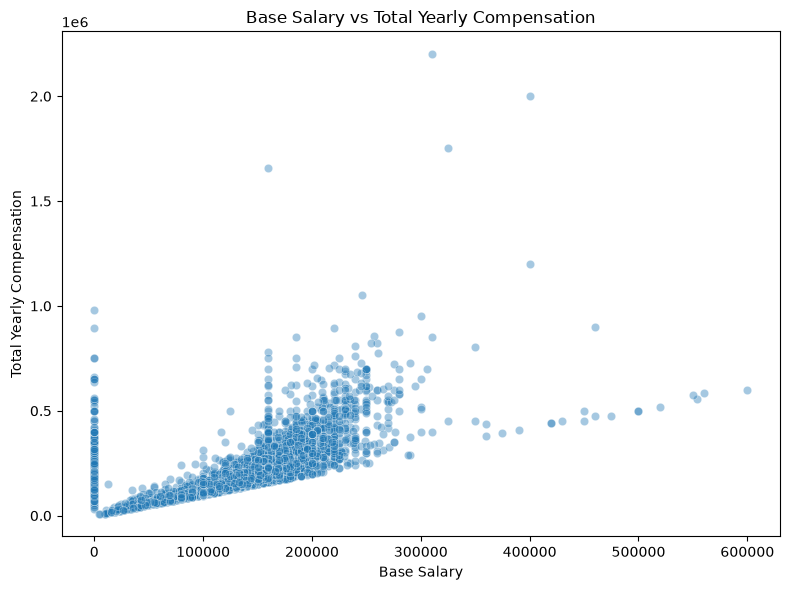

In [71]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df.sample(min(5000, len(df)),random_state=42),x="basesalary",y="totalyearlycompensation",alpha=0.4)
plt.xlabel("Base Salary")
plt.ylabel("Total Yearly Compensation")
plt.title("Base Salary vs Total Yearly Compensation")
plt.tight_layout()

### Feature Selection Decision

The compensation variables will not be used as predictors of `basesalary` because they represent closely related components or aggregates of employee compensation.

Using these variables would allow the model to obtain information that would not be available from independent employee characteristics and could therefore produce misleadingly strong performance.

The final predictive feature set will instead focus on professional, workplace, location, education, and demographic characteristics that can reasonably be treated as predictor variables.

## 12. Data Cleaning Decisions

Based on the initial data-quality analysis, preprocessing decisions will be made for missing values, zero salary observations, high-cardinality categorical variables, and potentially inconsistent records.

The goal is to retain as much valid information as possible while avoiding data leakage and excessive dimensionality.

In [72]:
zero_salary = df[df["basesalary"] == 0].copy()
zero_salary[["basesalary","totalyearlycompensation","stockgrantvalue","bonus","company","level","title","yearsofexperience","yearsatcompany"]].describe(include="all")

,basesalary,totalyearlycompensation,stockgrantvalue,bonus,company,level,title,yearsofexperience,yearsatcompany
count,2304.0,2.304000e+03,2304.000000,2304.000000,2304,2300,2304,2304.000000,2304.000000
unique,NaN,NaN,NaN,NaN,314,397,14,NaN,NaN
top,NaN,NaN,NaN,NaN,Amazon,L5,Software Engineer,NaN,NaN
freq,NaN,NaN,NaN,NaN,473,171,1536,NaN,NaN
mean,0.0,2.313668e+05,83.333333,42.534722,NaN,NaN,NaN,7.645182,3.290929
std,0.0,1.412496e+05,3170.231708,960.765633,NaN,NaN,NaN,5.804126,3.351985
min,0.0,1.200000e+04,0.000000,0.000000,NaN,NaN,NaN,0.000000,0.000000
25%,0.0,1.400000e+05,0.000000,0.000000,NaN,NaN,NaN,3.000000,1.000000
50%,0.0,2.000000e+05,0.000000,0.000000,NaN,NaN,NaN,6.000000,2.000000
75%,0.0,2.850000e+05,0.000000,0.000000,NaN,NaN,NaN,11.000000,4.500000


In [73]:
zero_salary[["totalyearlycompensation","stockgrantvalue","bonus","company","title"]].head(20)

,totalyearlycompensation,stockgrantvalue,bonus,company,title
281,75000,0.0,0.0,Facebook,Product Manager
284,137000,0.0,0.0,Booking.com,Product Designer
286,120000,0.0,0.0,Booking.com,Software Engineer
294,92000,0.0,0.0,Booking.com,Software Engineer
299,120000,0.0,0.0,Booking.com,Product Manager
300,216000,0.0,0.0,Uber,Software Engineer
309,72000,0.0,0.0,Booking.com,Product Designer
313,480000,0.0,0.0,Booking.com,Product Designer
314,100000,0.0,0.0,eBay,Software Engineer
351,198000,0.0,0.0,IBM,Solution Architect


### Zero Base Salary Observations

A small proportion of observations have a reported base salary of zero. These observations are not automatically treated as missing values because several contain non-zero total compensation and other compensation components.

The records will therefore be investigated before deciding whether they should be retained or excluded from the regression target.

## 13. Handling High-Cardinality Categorical Variables

Several categorical variables contain a large number of unique values.

In particular, `level` contains thousands of distinct values because companies use different naming conventions for employee seniority. Direct one-hot encoding would create a very high-dimensional feature space.

The modeling strategy will therefore prioritize categorical variables that provide useful information while keeping the feature space manageable.

In [74]:
df["title"].value_counts()

title
Software Engineer               41231
Product Manager                  4673
Software Engineering Manager     3569
Data Scientist                   2578
Hardware Engineer                2200
Product Designer                 1516
Technical Program Manager        1381
Solution Architect               1157
Management Consultant             976
Business Analyst                  885
Marketing                         710
Mechanical Engineer               490
Sales                             461
Recruiter                         451
Human Resources                   364
Name: count, dtype: int64

In [11]:
company_counts = df["company"].value_counts()
print("Number of companies:", df["company"].nunique())
print("\nTop 20 companies:")
display(company_counts.head(20))

Number of companies: 1067

Top 20 companies:


company
Amazon            8204
Microsoft         5252
Google            4368
Facebook          3004
Apple             2057
Oracle            1143
Salesforce        1065
Intel              992
Cisco              945
IBM                927
Uber               893
Capital One        786
LinkedIn           750
VMware             682
Qualcomm           578
JPMorgan Chase     558
Bloomberg          547
Goldman Sachs      475
PayPal             451
Intuit             450
Name: count, dtype: int64

In [12]:
location_counts = df["location"].value_counts()
print("Number of locations:", df["location"].nunique())
display(location_counts.head(20))

Number of locations: 1042


location
Seattle, WA                   8701
San Francisco, CA             6797
New York, NY                  4562
Redmond, WA                   2649
Mountain View, CA             2275
Sunnyvale, CA                 2248
San Jose, CA                  2047
Bangalore, KA, India          1724
Austin, TX                    1527
Menlo Park, CA                1440
Cupertino, CA                 1431
Santa Clara, CA               1196
Boston, MA                    1190
Palo Alto, CA                 1146
London, EN, United Kingdom    1024
San Diego, CA                  839
Chicago, IL                    806
Toronto, ON, Canada            742
Bellevue, WA                   737
Los Angeles, CA                714
Name: count, dtype: int64

### Categorical Feature Selection

The dataset contains several high-cardinality categorical variables. Rather than encoding every categorical field indiscriminately, variables will be selected based on their relevance, cardinality, and interpretability.

Job title, gender, education, and selected geographic information are candidates for inclusion. Variables with extremely high cardinality or inconsistent free-text values will be evaluated carefully before being included.

## 14. Date-Time Feature Analysis

The `timestamp` variable records when the salary response was collected. Because salary levels may change over time, the timestamp will be examined to determine whether useful temporal features can be extracted.

Rather than using the raw timestamp directly, relevant components such as collection year may be considered as engineered features.

In [13]:
df["timestamp"] = pd.to_datetime(df["timestamp"])
print("Earliest response:", df["timestamp"].min())
print("Latest response:", df["timestamp"].max())

Earliest response: 2017-06-07 11:33:00
Latest response: 2021-08-17 08:28:00


In [14]:
df["timestamp"].dt.year.value_counts().sort_index()

timestamp
2017      185
2018     3895
2019    11189
2020    23946
2021    23427
Name: count, dtype: int64

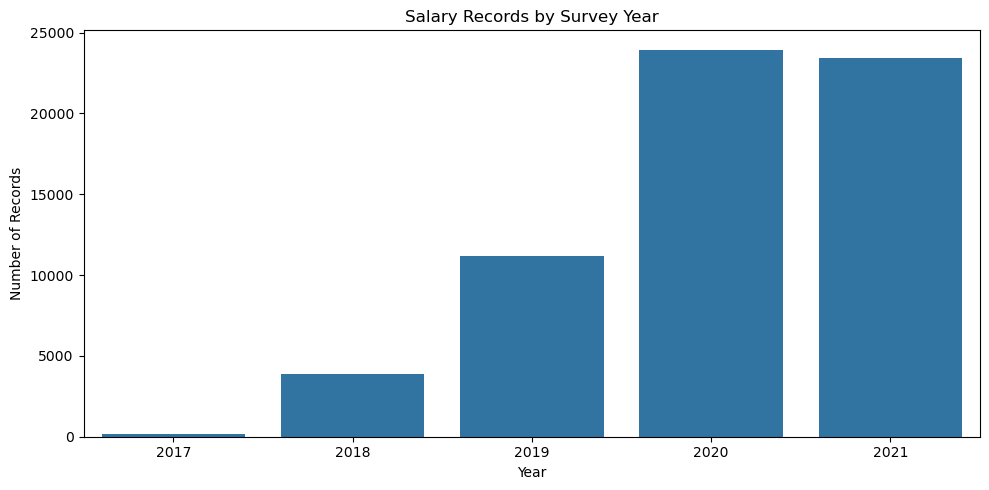

In [15]:
plt.figure(figsize=(10, 5))
sns.countplot(x=df["timestamp"].dt.year)
plt.xlabel("Year")
plt.ylabel("Number of Records")
plt.title("Salary Records by Survey Year")
plt.tight_layout()

## 15. Exploratory Gender Analysis

Gender is included as one of the demographic variables in the dataset. Since the project aims to investigate salary prediction in STEM, differences in salary distributions across reported gender groups will be explored descriptively.

This analysis will be treated as observational rather than causal. Differences in salary distributions should not be interpreted as evidence that gender itself causes a particular salary outcome.

In [16]:
gender_salary = (df[df["gender"].notna()].groupby("gender")["basesalary"].agg(["count", "mean", "median", "std"]).round(2))
gender_salary

,count,mean,median,std
gender,,,,
Female,6999,133823.2,135000.0,52151.28
Male,35702,136315.2,140000.0,59950.54


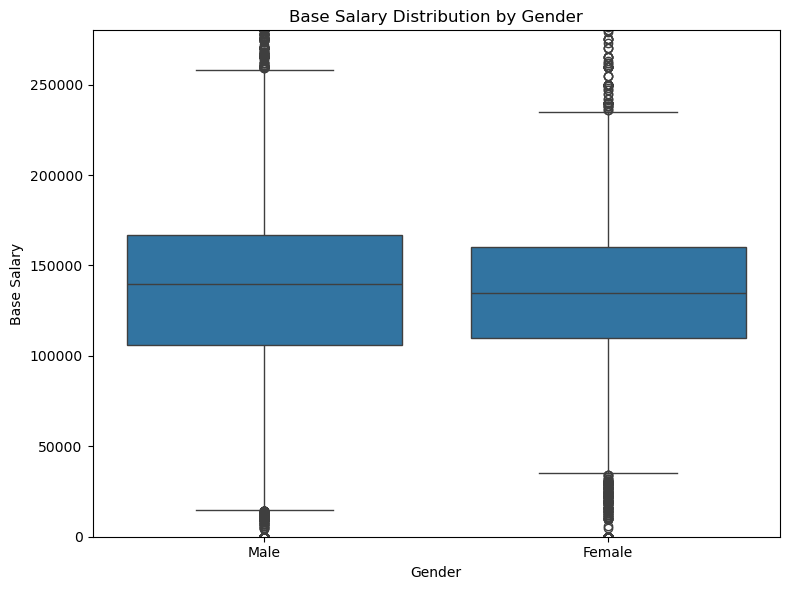

In [17]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=df[df["gender"].notna()],x="gender",y="basesalary")
plt.xlabel("Gender")
plt.ylabel("Base Salary")
plt.title("Base Salary Distribution by Gender")
plt.ylim(0, df["basesalary"].quantile(0.99))
plt.tight_layout()

## 16. Data Cleaning and Feature Selection

Based on the initial data-quality inspection, the dataset will be prepared for regression modeling.

The following decisions will be applied:

- Rows with zero `basesalary` will be excluded because a zero base salary is not a meaningful target value for this regression task.
- Compensation variables that directly describe total compensation or its components will not be used as predictors because they can introduce target leakage.
- Identifier and free-text fields that do not provide reliable predictive information will be excluded.
- Extremely high-cardinality variables will be excluded to avoid excessive dimensionality and inconsistent categorical representations.
- Missing numerical values will be handled using median imputation within the preprocessing pipeline.
- Missing categorical values will be represented as an explicit `"Unknown"` category.
- Genuine extreme salary observations will not be removed solely because they are statistically unusual.

In [11]:
df_model = df[df["basesalary"] > 0].copy()
print("Original rows:", len(df))
print("Rows after removing zero salaries:", len(df_model))
print("Rows removed:", len(df) - len(df_model))

Original rows: 62642
Rows after removing zero salaries: 60338
Rows removed: 2304


In [12]:
df_model["experience_before_company"] = (df_model["yearsofexperience"] - df_model["yearsatcompany"])
df_model["experience_before_company"] = (df_model["experience_before_company"].clip(lower=0))

### Feature Engineering

A new feature, `experience_before_company`, was created by subtracting years at the current company from total years of experience.

This provides an estimate of experience accumulated before joining the employee's current company and may capture information that is not represented by either experience variable independently.

The resulting value was constrained to be non-negative because negative prior-company experience would be logically inconsistent.

## 17. Predictor Selection

The target variable is `basesalary`.

The selected predictors represent professional experience, workplace characteristics, education, demographic information, and geography.

The following variables are excluded:

- `totalyearlycompensation`, `stockgrantvalue`, and `bonus` because they are directly related to compensation and may cause target leakage.
- `row_number`, `order_received`, `cityid`, and `dmaid` because they are identifiers rather than meaningful employee characteristics.
- `tag` and `otherdetails` because they are free-text fields with inconsistent structure.
- `level` because it contains thousands of highly inconsistent categories across companies.
- `city` because it has high geographic cardinality and overlaps with other location information.
- `timestamp` because the raw timestamp is not required for the primary prediction task.

The company variable is retained because company-level differences can reasonably be associated with compensation.

In [13]:
features = ["company","title","nation","gender","race","education","yearsofexperience","yearsatcompany","experience_before_company"]
target = "basesalary"
X = df_model[features].copy()
y = df_model[target].copy()
print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

Feature matrix shape: (60338, 9)
Target shape: (60338,)


## 18. Train, Validation, and Test Split

The dataset will be divided into three subsets:

- 70% training data
- 15% validation data
- 15% held-out test data

The training data will be used for model fitting and cross-validation. The validation set will be used for model comparison after tuning, while the test set will remain untouched until final evaluation.

A fixed random seed is used to make the experiment reproducible.

In [14]:
from sklearn.model_selection import train_test_split
RANDOM_STATE = 42
X_train, X_temp, y_train, y_temp = train_test_split(X,y,test_size=0.30,random_state=RANDOM_STATE)
X_val, X_test, y_val, y_test = train_test_split(X_temp,y_temp,test_size=0.50,random_state=RANDOM_STATE)
print("Training set:", X_train.shape)
print("Validation set:", X_val.shape)
print("Test set:", X_test.shape)

Training set: (42236, 9)
Validation set: (9051, 9)
Test set: (9051, 9)


## 19. Baseline Model

Before training machine learning models, a simple baseline will be established.

For regression, the baseline predicts the mean base salary of the training data for every observation.

A useful machine learning model should outperform this baseline on unseen data.

In [15]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
baseline_prediction = y_train.mean()
baseline_mae = mean_absolute_error(y_val,np.full(len(y_val), baseline_prediction))
baseline_mse = mean_squared_error(y_val,np.full(len(y_val), baseline_prediction))
baseline_rmse = np.sqrt(baseline_mse)
baseline_r2 = r2_score(y_val,np.full(len(y_val), baseline_prediction))

print(f"Baseline Mean Salary: ${baseline_prediction:,.2f}")
print(f"Baseline MAE: ${baseline_mae:,.2f}")
print(f"Baseline RMSE: ${baseline_rmse:,.2f}")
print(f"Baseline R²: {baseline_r2:.4f}")

Baseline Mean Salary: $142,065.24
Baseline MAE: $38,871.78
Baseline RMSE: $54,098.18
Baseline R²: -0.0002


## 20. Preprocessing Pipeline

The preprocessing steps will be implemented using a scikit-learn pipeline to prevent data leakage.

### Numerical features

Missing numerical values will be replaced using the median, followed by standardization.

### Categorical features

Missing categorical values will be replaced with `"Unknown"` and categorical variables will be one-hot encoded.

Using the preprocessing pipeline ensures that imputation, scaling, and encoding parameters are learned only from the training data during model fitting.

In [16]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
numeric_features = ["yearsofexperience","yearsatcompany","experience_before_company"]
categorical_features = ["company","title","nation","gender","race","education"]
numeric_pipeline = Pipeline([("imputer", SimpleImputer(strategy="median")),("scaler", StandardScaler())])
categorical_pipeline = Pipeline([("imputer", SimpleImputer(strategy="constant",fill_value="Unknown")),("encoder", OneHotEncoder(handle_unknown="ignore"))])
preprocessor = ColumnTransformer([("num", numeric_pipeline, numeric_features),("cat", categorical_pipeline, categorical_features)])

## 21. Model Selection

Four regression algorithms will be compared:

1. **Linear Regression** — provides a simple interpretable linear baseline.
2. **Ridge Regression** — extends linear regression with regularization and is useful when the encoded feature space contains correlated variables.
3. **Random Forest Regressor** — captures nonlinear relationships and feature interactions without requiring linear assumptions.
4. **XGBoost Regressor** — provides a powerful gradient-boosted tree model for nonlinear tabular data.

Using models with different assumptions allows their predictive performance and trade-offs to be compared rather than relying on a single algorithm.

In [17]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(random_state=RANDOM_STATE),
    "Random Forest": RandomForestRegressor(random_state=RANDOM_STATE,n_jobs=-1),
    "XGBoost": XGBRegressor(random_state=RANDOM_STATE,n_jobs=-1,objective="reg:squarederror")
}

## 22. Model Pipelines

Each candidate regression model is combined with the same preprocessing pipeline.

Using a single pipeline ensures that missing-value imputation, feature scaling, and categorical encoding are fitted only on the corresponding training data. This prevents information from the validation or test sets from influencing preprocessing.

The same preprocessing strategy is therefore applied consistently when comparing the candidate models.

In [18]:
model_pipelines = {}
for name, model in models.items():
    model_pipelines[name] = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)])

print("Pipelines created for:")
for name in model_pipelines:
    print("-", name)

Pipelines created for:
- Linear Regression
- Ridge Regression
- Random Forest
- XGBoost


## 23. Initial Model Training and Validation

The four candidate models will first be trained using their default hyperparameters.

Their predictions will be evaluated on the validation set using Mean Absolute Error (MAE), Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and R².

This initial comparison provides a reference point before hyperparameter tuning.

In [13]:
results = []
for name, pipeline in model_pipelines.items():
    print(f"Training {name}...")
    pipeline.fit(X_train, y_train)
    predictions = pipeline.predict(X_val)
    mae = mean_absolute_error(y_val, predictions)
    mse = mean_squared_error(y_val, predictions)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_val, predictions)
    results.append({"Model": name,"MAE": mae,"MSE": mse,"RMSE": rmse,"R²": r2})
initial_results = pd.DataFrame(results)
initial_results.sort_values("RMSE")

Training Linear Regression...
Training Ridge Regression...
Training Random Forest...
Training XGBoost...


,Model,MAE,MSE,RMSE,R²
3,XGBoost,18923.373047,7.596026e+08,27560.888230,0.740411
1,Ridge Regression,19709.476469,7.994142e+08,28273.913800,0.726805
0,Linear Regression,19786.949411,8.062066e+08,28393.778274,0.724484
2,Random Forest,19491.306042,8.383299e+08,28953.927407,0.713506


## 24. Initial Model Comparison

The initial models are compared with the mean-prediction baseline.

A useful regression model should substantially improve upon the baseline, particularly in terms of MAE, RMSE, and R².

In [14]:
baseline_row = pd.DataFrame([{"Model": "Mean Baseline","MAE": baseline_mae,"MSE": baseline_mse,"RMSE": baseline_rmse,"R²": baseline_r2}])
comparison_initial = pd.concat([baseline_row, initial_results],ignore_index=True)
comparison_initial.sort_values("RMSE")

,Model,MAE,MSE,RMSE,R²
4,XGBoost,18923.373047,7.596026e+08,27560.888230,0.740411
2,Ridge Regression,19709.476469,7.994142e+08,28273.913800,0.726805
1,Linear Regression,19786.949411,8.062066e+08,28393.778274,0.724484
3,Random Forest,19491.306042,8.383299e+08,28953.927407,0.713506
0,Mean Baseline,38871.782669,2.926613e+09,54098.177999,-0.000152


### Initial Model Performance

The validation RMSE values are compared to visualize the relative prediction error of the candidate models before hyperparameter tuning.

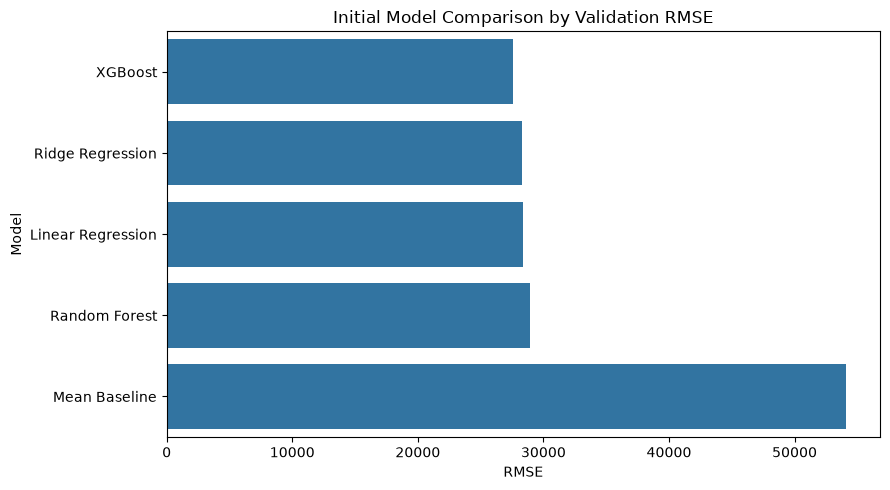

In [15]:
plt.figure(figsize=(9, 5))
plot_data = comparison_initial.sort_values("RMSE")
sns.barplot(data=plot_data,x="RMSE",y="Model")
plt.xlabel("RMSE")
plt.ylabel("Model")
plt.title("Initial Model Comparison by Validation RMSE")
plt.tight_layout()

### Cross-Validation Model Comparison

Before selecting candidates for hyperparameter tuning, the four models are compared using cross-validation rather than a single train/validation split. This gives a more reliable estimate of each model's generalization performance and reduces the risk that the earlier single-split ranking was influenced by how that particular split happened to fall.

**Computational tradeoff:** Running full 5-fold CV on the entire training set for all four models (including Random Forest and XGBoost) is expensive. Since the goal at this stage is to *rank* the models relative to one another, not to produce a final performance estimate, cross-validation is run on a 30% random subsample of the training data with 3 folds instead of 5. This keeps the relative ranking meaningful while making the step computationally feasible. The full training data is still used later for final model training and evaluation.

Negative RMSE is used as the scoring metric (scikit-learn's convention for "higher is better" scorers), then negated back to RMSE for reporting.

In [80]:
from sklearn.model_selection import cross_val_score, KFold

X_train_cv = X_train.sample(frac=0.3, random_state=RANDOM_STATE)
y_train_cv = y_train.loc[X_train_cv.index]

cv = KFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

cv_results = []
for name, pipeline in model_pipelines.items():
    scores = cross_val_score(pipeline, X_train_cv, y_train_cv, cv=cv,scoring="neg_root_mean_squared_error", n_jobs=-1)
    cv_rmse = -scores
    cv_results.append({
        "Model": name,
        "CV RMSE Mean": cv_rmse.mean(),
        "CV RMSE Std": cv_rmse.std()
    })

cv_comparison = pd.DataFrame(cv_results).sort_values("CV RMSE Mean").reset_index(drop=True)
cv_comparison

,Model,CV RMSE Mean,CV RMSE Std
0,Ridge Regression,31496.395483,3856.712122
1,Linear Regression,31995.210744,3780.258972
2,XGBoost,32331.123047,3411.358833
3,Random Forest,33669.225691,3061.614460


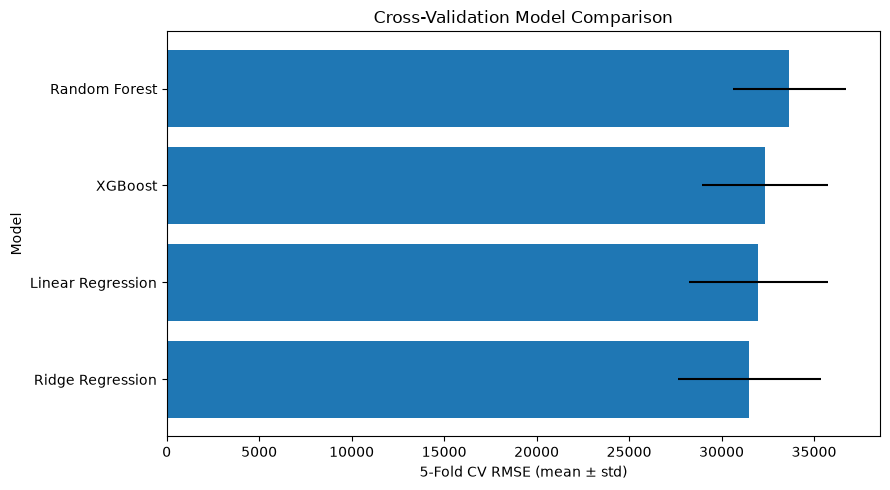

In [81]:
plt.figure(figsize=(9, 5))
plot_data = cv_comparison.sort_values("CV RMSE Mean")
plt.barh(plot_data["Model"], plot_data["CV RMSE Mean"], xerr=plot_data["CV RMSE Std"])
plt.xlabel("5-Fold CV RMSE (mean ± std)")
plt.ylabel("Model")
plt.title("Cross-Validation Model Comparison")
plt.tight_layout()

**Interpretation:** The cross-validation ranking (computed on a 30% subsample, 3-fold) is compared against the earlier single-split ranking on the full validation set. If the two rankings agree, this increases confidence that the earlier model selection was not an artifact of a lucky or unlucky split. The standard deviation across folds also gives a sense of how variable each model's performance is, independent of the specific random seed used for the split. Because this step uses a subsample, its role is to sanity-check the ranking, not to serve as the final reported performance metric — that role remains with the full held-out test set evaluated later.

## 25. Hyperparameter Tuning

Hyperparameter tuning will be performed using cross-validation on the training data.

Ridge Regression and XGBoost will be tuned because their performance depends on important regularization, tree-complexity, and boosting parameters.

RandomizedSearchCV will be used to efficiently explore a range of hyperparameter combinations.

The validation and test sets will not be used during hyperparameter optimization.

In [19]:
from sklearn.model_selection import RandomizedSearchCV

In [20]:
ridge_pipeline = model_pipelines["Ridge Regression"]
ridge_params = {"model__alpha": [0.01, 0.1, 1, 10, 100, 1000]}
ridge_search = RandomizedSearchCV(estimator=ridge_pipeline,param_distributions=ridge_params,n_iter=6,cv=5,scoring="neg_root_mean_squared_error",random_state=RANDOM_STATE,n_jobs=-1)
ridge_search.fit(X_train, y_train)

print("Best Ridge parameters:")
print(ridge_search.best_params_)

print(f"\nBest CV RMSE: {-ridge_search.best_score_:.2f}")

Best Ridge parameters:
{'model__alpha': 1}

Best CV RMSE: 30457.08


In [22]:
xgb_pipeline = model_pipelines["XGBoost"]
xgb_params = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [3, 5],
    "model__learning_rate": [0.05, 0.1],
    "model__subsample": [0.8, 1.0],
}
xgb_search = RandomizedSearchCV(estimator=xgb_pipeline,param_distributions=xgb_params,n_iter=8,cv=3,scoring="neg_root_mean_squared_error",random_state=RANDOM_STATE,n_jobs=-1)
xgb_search.fit(X_train, y_train)

print("Best XGBoost parameters:")
print(xgb_search.best_params_)
print(f"\nBest CV RMSE: {-xgb_search.best_score_:.2f}")

Best XGBoost parameters:
{'model__subsample': 0.8, 'model__n_estimators': 200, 'model__max_depth': 5, 'model__learning_rate': 0.1}

Best CV RMSE: 30770.56


## 26. Tuned Model Validation

The best estimator from each hyperparameter search will be evaluated on the held-out validation set.

The validation results will be compared with the untuned models and the baseline to determine which approach provides the strongest generalization performance before final testing.

In [23]:
tuned_models = {"Ridge Tuned": ridge_search.best_estimator_, "XGBoost Tuned": xgb_search.best_estimator_}
tuned_results = []
for name, model in tuned_models.items():
    predictions = model.predict(X_val)
    mse = mean_squared_error(y_val, predictions)
    tuned_results.append({"Model": name,"MAE": mean_absolute_error(y_val, predictions),"MSE": mse,"RMSE": np.sqrt(mse),"R²": r2_score(y_val, predictions)})
tuned_results = pd.DataFrame(tuned_results)
tuned_results.sort_values("RMSE")

,Model,MAE,MSE,RMSE,R²
1,XGBoost Tuned,19592.132812,7.776714e+08,27886.759582,0.734236
0,Ridge Tuned,19709.476469,7.994142e+08,28273.913800,0.726805


## 27. Overall Model Comparison

The tuned models are compared with the initial candidate models using the validation set.

This comparison allows the effect of hyperparameter tuning to be assessed and provides a basis for selecting the final model.

RMSE is used as the primary selection metric because it penalizes larger prediction errors more strongly, while MAE and R² are considered as additional measures of model performance.

In [24]:
all_validation_results = pd.concat([initial_results, tuned_results],ignore_index=True)
all_validation_results = (all_validation_results.drop_duplicates(subset="Model").sort_values("RMSE").reset_index(drop=True))
all_validation_results

,Model,MAE,MSE,RMSE,R²
0,XGBoost,18923.373047,7.596026e+08,27560.888230,0.740411
1,XGBoost Tuned,19592.132812,7.776714e+08,27886.759582,0.734236
2,Ridge Tuned,19709.476469,7.994142e+08,28273.913800,0.726805
3,Ridge Regression,19709.476469,7.994142e+08,28273.913800,0.726805
4,Linear Regression,19786.949411,8.062066e+08,28393.778274,0.724484
5,Random Forest,19491.306042,8.383299e+08,28953.927407,0.713506


## 28. Final Model Selection

Based on validation-set performance, the default XGBoost Regressor achieved the lowest RMSE and MAE and the highest R² among the candidate models.

Therefore, XGBoost is selected as the final model for evaluation on the held-out test set.

Interestingly, the tuned XGBoost model did not outperform the default configuration. This indicates that the default configuration was already well suited to the current feature representation and dataset.

In [25]:
best_model_name = "XGBoost"
best_model = model_pipelines["XGBoost"]
print("Selected final model:", best_model_name)

Selected final model: XGBoost


## 29. Final Model Training

After model selection, the training and validation datasets are combined to provide the final model with all available development data.

The test set remains completely untouched and will only be used for the final evaluation.

In [26]:
X_train_final = pd.concat([X_train, X_val])
y_train_final = pd.concat([y_train, y_val])

print("Final training data shape:", X_train_final.shape)
print("Final training target shape:", y_train_final.shape)

Final training data shape: (51287, 9)
Final training target shape: (51287,)


In [27]:
best_model.fit(X_train_final, y_train_final)
final_predictions = best_model.predict(X_test)

## 30. Final Evaluation on the Held-Out Test Set

The selected XGBoost model is evaluated on the held-out test set.

The test data was not used during preprocessing, hyperparameter tuning, or model selection. Therefore, these results provide an unbiased estimate of the model's performance on unseen observations.

The model is evaluated using MAE, MSE, RMSE, and R².

In [43]:
final_mae = mean_absolute_error(y_test, final_predictions)
final_mse = mean_squared_error(y_test, final_predictions)
final_rmse = np.sqrt(final_mse)
final_r2 = r2_score(y_test, final_predictions)

final_results = pd.DataFrame({"Metric": ["MAE", "MSE", "RMSE", "R²"],"Value": [final_mae,final_mse,final_rmse,final_r2]})
final_results

,Metric,Value
0,MAE,1.920099e+04
1,MSE,8.873059e+08
2,RMSE,2.978768e+04
3,R²,7.329258e-01


## 31. Actual vs Predicted Salary

The relationship between actual and predicted base salary is visualized to assess how closely the model's predictions follow the observed values.

Points closer to the 45-degree reference line represent more accurate predictions, while larger deviations indicate greater prediction error.

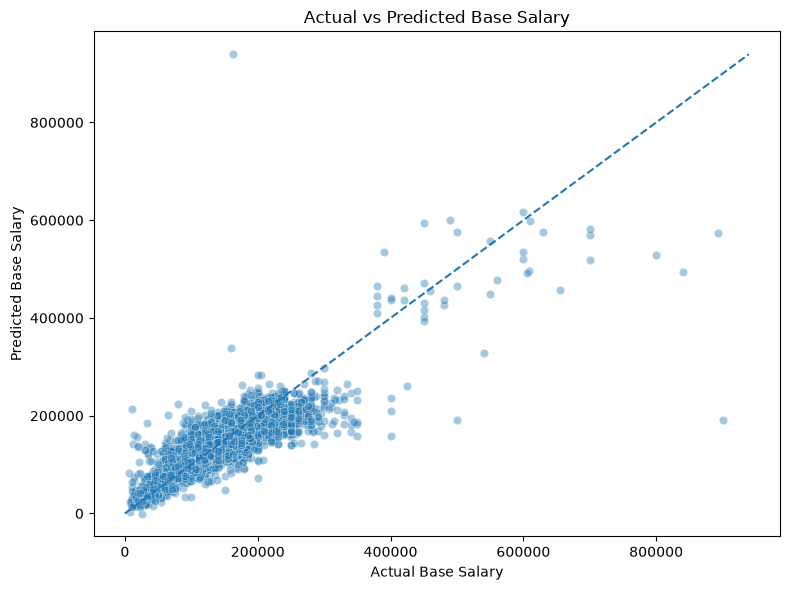

In [29]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test,y=final_predictions,alpha=0.4)
min_value = min(y_test.min(), final_predictions.min())
max_value = max(y_test.max(), final_predictions.max())
plt.plot([min_value, max_value],[min_value, max_value],linestyle="--")
plt.xlabel("Actual Base Salary")
plt.ylabel("Predicted Base Salary")
plt.title("Actual vs Predicted Base Salary")
plt.tight_layout()

## 32. Residual Analysis

Residuals represent the difference between the actual and predicted base salary.

Residual plots are examined to identify systematic patterns, unusually large errors, and changes in error magnitude across the range of predicted salaries.

In [30]:
residuals = y_test - final_predictions

print("Mean residual:", residuals.mean())
print("Median residual:", residuals.median())

Mean residual: -299.26659097356463
Median residual: -1727.46875


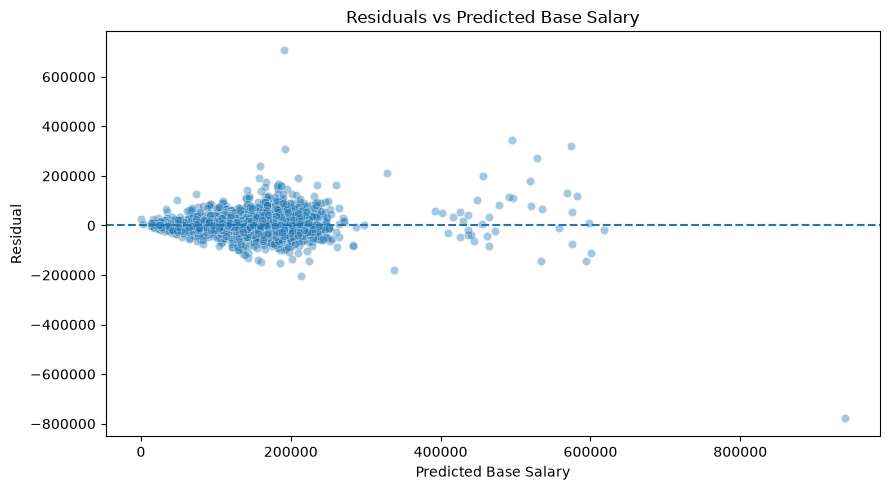

In [31]:
plt.figure(figsize=(9, 5))
sns.scatterplot(x=final_predictions,y=residuals,alpha=0.4)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted Base Salary")
plt.ylabel("Residual")
plt.title("Residuals vs Predicted Base Salary")
plt.tight_layout()

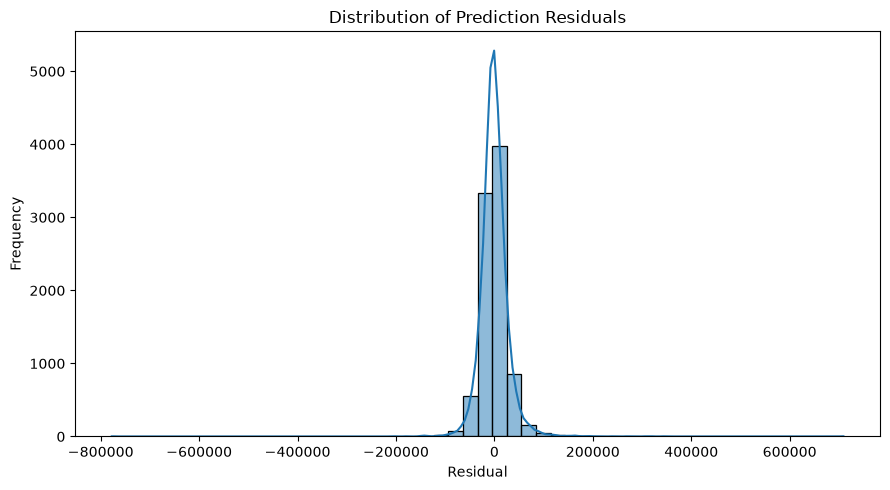

In [32]:
plt.figure(figsize=(9, 5))
sns.histplot(residuals,bins=50,kde=True)
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("Distribution of Prediction Residuals")
plt.tight_layout()

### Residual Interpretation

The residual distribution and residual-versus-predicted plot are used to assess whether the model produces systematic prediction errors.

Ideally, residuals should be centered around zero without a strong systematic pattern. Large deviations from zero indicate observations for which the model has greater prediction error.

## 33. Largest Prediction Errors

The observations with the largest absolute prediction errors are examined to identify whether prediction errors are concentrated among particular salary levels, job titles, companies, or other characteristics.

In [34]:
error_analysis = X_test.copy()
error_analysis["Actual Salary"] = y_test
error_analysis["Predicted Salary"] = final_predictions
error_analysis["Residual"] = residuals
error_analysis["Absolute Error"] = np.abs(residuals)
error_analysis.sort_values("Absolute Error",ascending=False).head(15)

,company,title,nation,gender,race,education,yearsofexperience,yearsatcompany,experience_before_company,Actual Salary,Predicted Salary,Residual,Absolute Error
28242,SquareSpace,Software Engineer,United States,Male,NaN,NaN,7.0,7.0,0.0,162000,939501.125000,-777501.125000,777501.125000
31890,PwC,Management Consultant,United States,Male,Asian,Master's Degree,22.0,4.0,18.0,900000,190794.656250,709205.343750,709205.343750
18084,Netflix,Software Engineer,United States,NaN,NaN,NaN,20.0,6.0,14.0,840000,495063.625000,344936.375000,344936.375000
18085,Netflix,Software Engineer,United States,Male,White,Bachelor's Degree,19.0,8.0,11.0,893000,573616.437500,319383.562500,319383.562500
41431,DoorDash,Software Engineer,United States,NaN,NaN,NaN,9.0,1.0,8.0,500000,192157.734375,307842.265625,307842.265625
18133,Netflix,Software Engineering Manager,United States,Male,Asian,Bachelor's Degree,8.0,3.0,5.0,800000,529000.375000,270999.625000,270999.625000
27806,Jane Street,Software Engineer,United States,Male,NaN,NaN,7.0,4.0,3.0,400000,158968.125000,241031.875000,241031.875000
18292,Netflix,Software Engineer,United States,NaN,NaN,NaN,5.5,3.5,2.0,540000,328749.656250,211250.343750,211250.343750
36695,Google,Software Engineering Manager,United States,Male,NaN,NaN,9.0,7.0,2.0,10000,213244.265625,-203244.265625,203244.265625
18255,Netflix,Data Scientist,United States,Male,NaN,NaN,5.0,2.0,3.0,655000,456944.718750,198055.281250,198055.281250


## 34. Feature Importance

The XGBoost model's feature importance values are examined to identify which encoded predictors contribute most strongly to the model's predictions.

Feature importance indicates predictive contribution within the trained model and should not be interpreted as evidence of a causal relationship with salary.

In [75]:
fitted_preprocessor = best_model.named_steps["preprocessor"]
feature_names = fitted_preprocessor.get_feature_names_out()
importances = best_model.named_steps["model"].feature_importances_

print("Number of processed features:", len(feature_names))
print("Number of feature importances:", len(importances))

feature_importance = pd.DataFrame({"Feature": feature_names,"Importance": importances}).sort_values("Importance",ascending=False)
feature_importance.head(20)

Number of processed features: 1175
Number of feature importances: 1175


,Feature,Importance
638,cat__company_Netflix,0.152115
1154,cat__nation_United States,0.114667
1107,cat__nation_India,0.028865
355,cat__company_Facebook,0.015735
444,cat__company_Here Technologies,0.013138
57,cat__company_Amazon,0.012275
142,cat__company_Bloomberg,0.011607
1137,cat__nation_Russia,0.011511
1146,cat__nation_Switzerland,0.010454
794,cat__company_Salesforce,0.010187


### Top Predictive Features

The most important features are visualized to make the model's predictive structure easier to interpret.

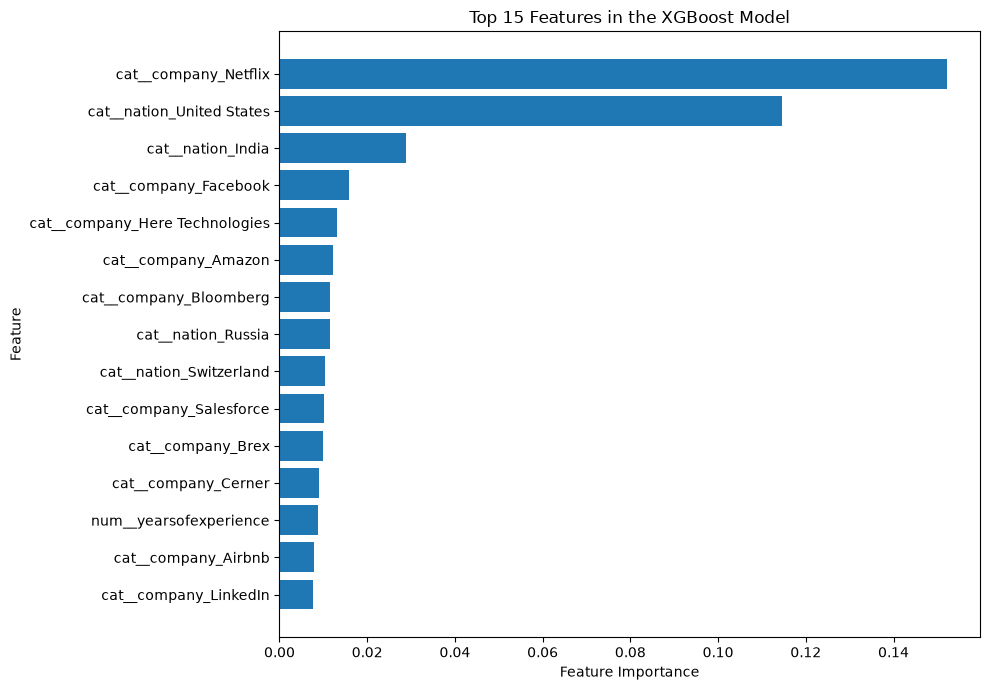

In [36]:
top_features = feature_importance.head(15).sort_values("Importance")
plt.figure(figsize=(10, 7))
plt.barh(top_features["Feature"],top_features["Importance"])
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 15 Features in the XGBoost Model")
plt.tight_layout()

### Partial Dependence Plots

Partial dependence plots (PDPs) show the estimated marginal effect of a single feature on predicted base salary, averaging over all other features. This complements the feature importance ranking by showing not just *that* a feature matters, but *how* it relates to the prediction — e.g., whether the relationship is roughly linear, saturating, or non-monotonic.

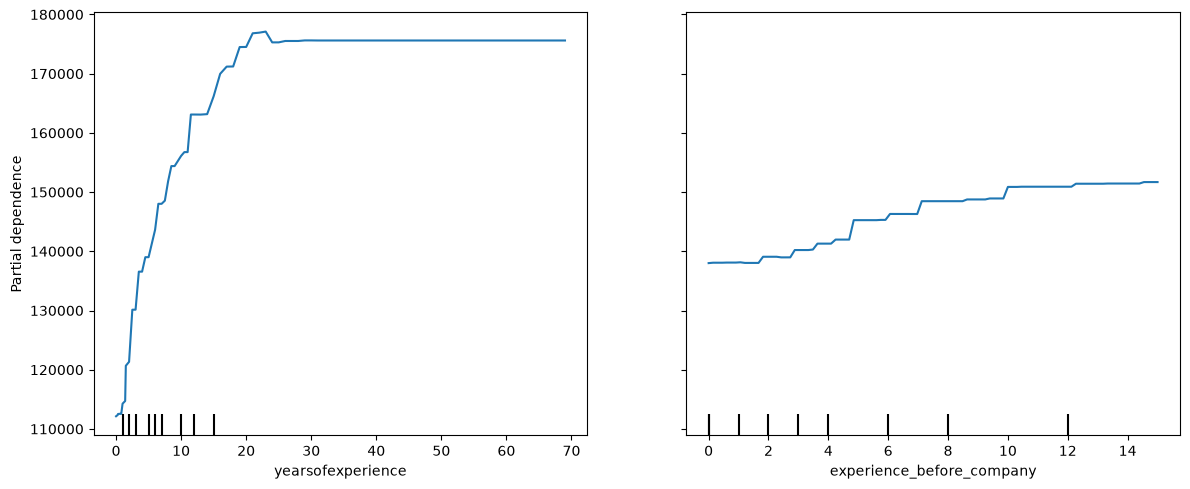

In [82]:
from sklearn.inspection import PartialDependenceDisplay
pdp_features = ["yearsofexperience", "experience_before_company"]
fig, ax = plt.subplots(figsize=(12, 5))
PartialDependenceDisplay.from_estimator(best_model, X_train_final, features=pdp_features, ax=ax)
plt.tight_layout()

**Interpretation:** The partial dependence curves are expected to show base salary increasing with years of experience, likely with diminishing returns at higher experience levels as the model captures a saturating relationship rather than a strictly linear one. As with the feature importance and coefficient analyses above, these are associational patterns learned by the model and should not be read as causal experience-to-salary effects.

## 34.1 Linear Model Coefficient Analysis

While tree-based feature importance shows which encoded variables contribute most strongly to XGBoost predictions, linear model coefficients provide an interpretable view of the direction and magnitude of associations in the Ridge Regression model.

Because categorical variables are one-hot encoded, each coefficient represents the model's estimated contribution relative to the corresponding reference representation, while numerical coefficients reflect the effect of a one-standard-deviation change in the standardized feature.

These coefficients describe model associations and should not be interpreted as causal effects.

In [21]:
ridge_model = ridge_search.best_estimator_
ridge_preprocessor = ridge_model.named_steps["preprocessor"]
ridge_features = ridge_preprocessor.get_feature_names_out()
ridge_coefficients = ridge_model.named_steps["model"].coef_
ridge_coefs = pd.DataFrame({"Feature": ridge_features,"Coefficient": ridge_coefficients})
ridge_coefs["Absolute Coefficient"] = np.abs(ridge_coefs["Coefficient"])
ridge_coefs.sort_values("Absolute Coefficient",ascending=False).head(15)

,Feature,Coefficient,Absolute Coefficient
638,cat__company_Netflix,306026.376169,306026.376169
155,cat__company_Brex,137651.011072,137651.011072
166,cat__company_CA Technologies,90413.746267,90413.746267
776,cat__company_Roku,87586.440372,87586.440372
464,cat__company_ING,84261.774557,84261.774557
1148,cat__nation_United Arab Emirates,80307.264782,80307.264782
1142,cat__nation_Switzerland,73961.143072,73961.143072
500,cat__company_Jane Street,69473.735216,69473.735216
1009,cat__company_Wepay,69354.245045,69354.245045
774,cat__company_Roblox,69317.497014,69317.497014


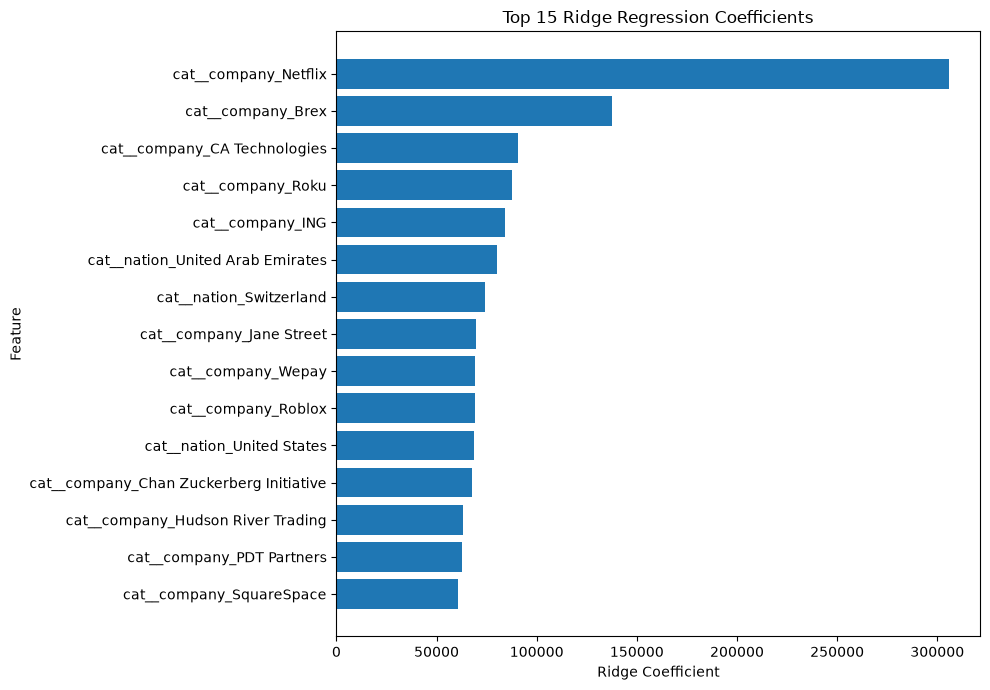

In [22]:
top_ridge = (ridge_coefs.sort_values("Absolute Coefficient", ascending=False).head(15).sort_values("Coefficient"))
plt.figure(figsize=(10, 7))
plt.barh(top_ridge["Feature"],top_ridge["Coefficient"])
plt.xlabel("Ridge Coefficient")
plt.ylabel("Feature")
plt.title("Top 15 Ridge Regression Coefficients")
plt.tight_layout()

## 35. Robustness Across Random Seeds

To assess whether model performance depends strongly on a particular random split, the selected XGBoost pipeline is evaluated using several different random seeds.

The resulting metrics are compared to determine whether performance remains reasonably stable across different train-test partitions.

In [76]:
from sklearn.base import clone

In [77]:
seeds = [21, 42, 100]
robustness_results = []
for seed in seeds:
    X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X,y,test_size=0.20,random_state=seed)
    model_r = XGBRegressor(random_state=seed,n_jobs=-1,objective="reg:squarederror")
    pipeline_r = Pipeline([("preprocessor", preprocessor),("model", model_r)])
    pipeline_r.fit(X_train_r, y_train_r)
    predictions_r = pipeline_r.predict(X_test_r)
    robustness_results.append({"Random State": seed,"MAE": mean_absolute_error(y_test_r, predictions_r),"RMSE": np.sqrt(mean_squared_error(y_test_r, predictions_r)),"R²": r2_score(y_test_r, predictions_r)})
robustness_results = pd.DataFrame(robustness_results)
robustness_results

,Random State,MAE,RMSE,R²
0,21,18964.457031,28424.856728,0.734854
1,42,18944.007812,28075.826470,0.744221
2,100,19481.132812,32299.425134,0.676744


### Robustness Interpretation

The model performs similarly for random seeds 21 and 42, with R² values of approximately 0.735 and 0.744.

Performance decreases for seed 100, where R² falls to approximately 0.677 and RMSE increases.

This indicates that the model is reasonably stable across some splits but remains sensitive to the composition of the training and evaluation data. This is expected for a dataset containing substantial variation in salaries and relatively rare high-salary observations.

The original held-out test result remains the primary reported performance estimate.

In [78]:
best_model.fit(X_train_final, y_train_final)
final_predictions = best_model.predict(X_test)

## 36. Learning Curve

A learning curve is used to examine how model performance changes as the amount of training data increases.

This provides insight into whether additional training data may improve model performance or whether the model has reached a relatively stable performance level.

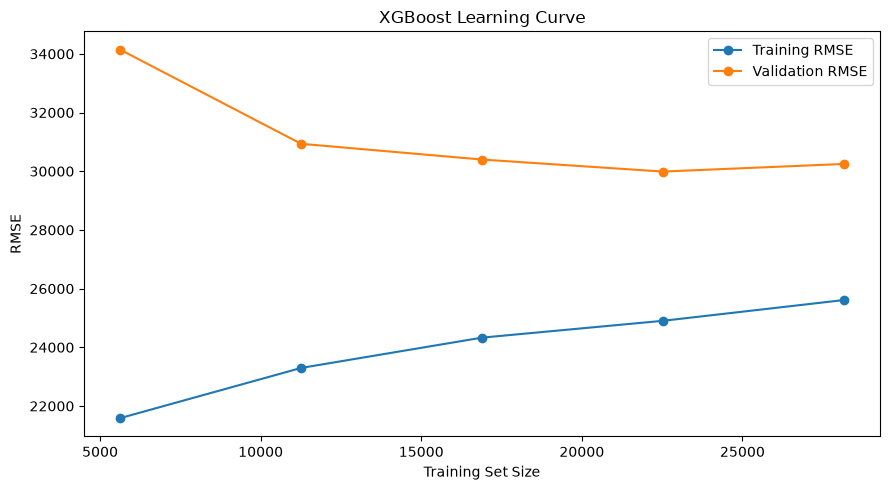

In [38]:
from sklearn.model_selection import learning_curve
train_sizes, train_scores, validation_scores = learning_curve(best_model,X_train,y_train,cv=3,scoring="neg_root_mean_squared_error",train_sizes=np.linspace(0.2, 1.0, 5),n_jobs=-1)

train_rmse = -train_scores.mean(axis=1)
validation_rmse = -validation_scores.mean(axis=1)

plt.figure(figsize=(9, 5))
plt.plot(train_sizes,train_rmse,marker="o",label="Training RMSE")
plt.plot(train_sizes,validation_rmse,marker="o",label="Validation RMSE")

plt.xlabel("Training Set Size")
plt.ylabel("RMSE")
plt.title("XGBoost Learning Curve")
plt.legend()
plt.tight_layout()


## 37. Saving the Final Model

The complete XGBoost preprocessing and prediction pipeline is saved as a single serialized model.

Saving the complete pipeline ensures that the same preprocessing operations are applied when the model is later used for prediction.

In [39]:
import joblib
joblib.dump(best_model,"final_salary_prediction_model.pkl")
print("Final model saved successfully.")

Final model saved successfully.


## 38. Reproducibility

A fixed random seed of 42 was used as the primary random state throughout the project.

The project uses NumPy, Pandas, Matplotlib, Seaborn, Scikit-learn, and XGBoost.

Project dependencies are documented in the accompanying environment files.

In [50]:
import numpy
import pandas
import sklearn
import xgboost

print("NumPy:", numpy.__version__)
print("Pandas:", pandas.__version__)
print("Scikit-learn:", sklearn.__version__)
print("XGBoost:", xgboost.__version__)

NumPy: 2.5.2
Pandas: 3.0.5
Scikit-learn: 1.9.0
XGBoost: 3.4.1


## 39. Final Results Summary

The final XGBoost model is evaluated on the held-out test set using the required regression metrics.

In [55]:
final_summary = pd.DataFrame({
    "Metric": ["MAE", "MSE", "RMSE", "R²"],
    "Value": [f"USD {final_mae:,.2f}",f"USD {final_mse:,.2f}",f"USD {final_rmse:,.2f}",f"{final_r2:.4f}"]})
final_summary

,Metric,Value
0,MAE,"USD 19,200.99"
1,MSE,"USD 887,305,856.00"
2,RMSE,"USD 29,787.68"
3,R²,0.7329


## 40. Final Findings

The final XGBoost model achieved the following performance on the held-out test set:

- MAE: approximately 19,201
- RMSE: approximately 29,788
- R²: approximately 0.733

The model therefore explains approximately 73% of the variation in base salary on unseen test observations.

Among the candidate models, XGBoost achieved the strongest validation performance. Ridge Regression was also competitive, while Linear Regression and Random Forest produced lower validation performance.

The tuned XGBoost configuration did not outperform the default XGBoost configuration on the validation set, indicating that the default configuration was already effective for this feature representation.

## 41. Limitations and Responsible Interpretation

Several limitations should be considered when interpreting the results.

1. The dataset is based on an online survey, so the observations may not represent the entire STEM workforce.

2. Several demographic and education variables contain substantial missingness. Missing values were retained as an explicit category for categorical predictors rather than assuming that missing responses represented a particular demographic group.

3. Salary distributions contain extreme observations. These were not automatically removed because unusually high salaries may represent genuine observations.

4. The model identifies predictive relationships but does not establish causal relationships. In particular, differences in predicted or observed salary across demographic groups should not be interpreted as evidence that demographic characteristics cause salary differences.

5. The model's performance is measured using historical survey data and may not generalize equally well to other populations, industries, countries, or future salary conditions.

6. Company, job title, experience, education, and demographic variables may reflect complex relationships and interactions that cannot be interpreted as isolated causal effects.

## 42. Conclusion

This project developed an end-to-end machine learning workflow for predicting base salary among STEM workers.

The workflow included data inspection, data cleaning, feature engineering, leakage prevention, train-validation-test splitting, preprocessing, baseline comparison, multiple regression models, cross-validation, hyperparameter tuning, final test evaluation, residual analysis, feature-importance analysis, and robustness testing.

XGBoost achieved the strongest validation performance among the candidate models.

On the held-out test set, the final model achieved an R² of approximately 0.733, with an MAE of approximately USD 19,201 and an RMSE of approximately USD 29,788.

The results demonstrate that professional, workplace, educational, demographic, and geographic characteristics can provide substantial predictive information about salary. However, the model should be viewed as a predictive tool rather than a causal explanation of salary differences.